In [30]:
# Librerias 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
os.chdir("C:/Users/David Barbina/Desktop/Archivos EBAC/RH")

df = pd.read_csv("recursos_humanos.csv")

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [25]:
# Exploración de datos
print(df["Work_accident"].value_counts())
print(df["left"].value_counts())
print(df["sales"].value_counts())
print(df["time_spend_company"].value_counts())

# Estos resultados arrojan que "Work_accidnt" , "left" son variables no quilibradas, mientras que las columnas "sales" y "timpe_spend_company" están más dispersas entre sus resultados, la razón podría ser el número de salidas posibles, entre más haya parece estár más disperso.

Work_accident
0    12830
1     2169
Name: count, dtype: int64
left
0    11428
1     3571
Name: count, dtype: int64
sales
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64
time_spend_company
3     6443
2     3244
4     2557
5     1473
6      718
10     214
7      188
8      162
Name: count, dtype: int64


In [31]:
df = pd.get_dummies(df, columns=["sales","salary"], dtype=int)

In [32]:
y = df.left.values
x_df = df.drop(["left"], axis=1)

In [33]:
# Normalización
x = (x_df - x_df.min()) / (x_df.max() - x_df.min())
x

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_IT,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,0.318681,0.265625,0.0,0.285047,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.780220,0.781250,0.6,0.775701,0.500,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.021978,0.812500,1.0,0.822430,0.250,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.692308,0.796875,0.6,0.593458,0.375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.307692,0.250000,0.0,0.294393,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.340659,0.328125,0.0,0.257009,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
14995,0.307692,0.187500,0.0,0.299065,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
14996,0.307692,0.265625,0.0,0.219626,0.125,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
14997,0.021978,0.937500,0.8,0.859813,0.250,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


Score:  0.9617777777777777


Text(33.22222222222222, 0.5, 'y verdadera')

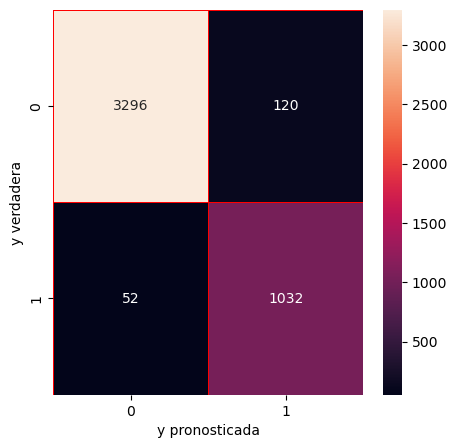

In [61]:
# Bases de entrenamiento y prueba
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.30, random_state=1)

# Modelo KNN (K vecinos más cercanos)
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1) # Esta fue la K óptima
knn.fit(x_train, y_train)
prediction = knn.predict(x_test)
print("Score: ", knn.score(x_test,y_test))

y_pred = prediction
y_true = y_test

# Creación de la matriz de confusión
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true,y_pred)
cm

# Visualización de la matriz de confusión
import seaborn as sns
f, ax = plt.subplots(figsize=(5,5))

sns.heatmap(cm , annot=True, linewidths=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y pronosticada")
plt.ylabel("y verdadera")

In [62]:
# Calculo de la presición global
Correctos= cm[0,0] + cm[1,1]
Incorrectos = cm[0,1] + cm[1,0]

PrediccionGlobal = Correctos/(Correctos + Incorrectos)
PrediccionGlobal

np.float64(0.9617777777777777)

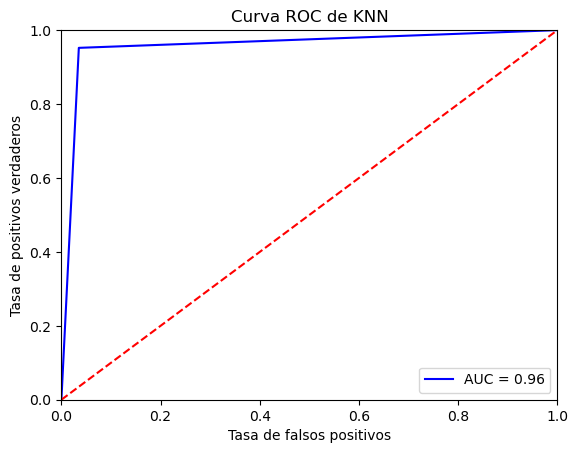

In [63]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc # Area bajo la curva

y_scores = knn.predict_proba(x_test)

fpr, tpr, threshold = roc_curve(y_test, y_scores[:,1]) # fpr = false positive rate, tpr = true positive rate
roc_auc = auc(fpr,tpr)

plt.title("Reciever Operating Characteristic")
plt.plot(fpr, tpr, "b", label="AUC = %0.2f" % roc_auc )
plt.legend(loc="lower right")
plt.plot([0,1], [0,1], "r--")
plt.xlim([0,1])
plt.ylim([0,1])
plt.ylabel("Tasa de positivos verdaderos")
plt.xlabel("Tasa de falsos positivos")
plt.title("Curva ROC de KNN")
plt.show()